# GSR Feature Extraction
With this notebook we extract GSR features per task per participant from preprocessed gsr files.
Aggregates across all exploration periods within each task.

**Output:** `gsr_features_all_participants.csv` with one row per task per participant containing:
- Raw features: `tonic_mean_uS`, `tonic_slope`, `scr_count`, `scr_rate`, `scr_amp_mean`, `scr_amp_sum`, `bc_mean_uS`
- Z-scored within participant: same columns with `_z` suffix

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [3]:
BASE_DIR = "/content/drive/MyDrive/CAMES/data_collection_training"

# Participants to process
PARTICIPANTS = [f"P{i:02d}" for i in range(1, 21)]  # P01 to P20

#Feature extraction settings
TARGET_FS         = 4      # Hz, we know that from the preprocessing parameters cell, after preprocessing every recording is downsampled to 4 Hz
SCR_MIN_DISTANCE  = 2      # seconds minimum between SCR peaks, without this the decay portion of a gsr signal peak could be mistakenly flagged as a second separate response
SCR_THRESHOLD_SD  = 0.5    # SCR threshold = mean + N * std of phasic signal

##Feature Extraction Function

In [4]:
def extract_gsr_features(preprocessed_file, participant):
    """
    Extract GSR features per task per participant.
    Aggregates across all exploration periods within each task.
    SCR detection runs per exploration to avoid false peaks at boundaries.
    Returns a DataFrame with one row per task.
    """
    df = pd.read_csv(preprocessed_file)

    # Remove artifact samples
    df = df[df["artifact_flag"] == 0].reset_index(drop=True)

    records = []
    min_dist = int(SCR_MIN_DISTANCE * TARGET_FS)

    for task_id in df[df["task_id"] != ""]["task_id"].unique():
        task_seg  = df[df["task_id"] == task_id]
        explo_seg = task_seg[task_seg["exploration_id"] > 0]  #here we define all the exploration period that fall into a certain task

        if len(explo_seg) < 2:
            print(f"  [SKIP] {task_id} — too few exploration samples ({len(explo_seg)})")
            continue

        # Total exploration duration — sum across individual explorations
        total_duration = sum(
            grp["timestamp_s"].iloc[-1] - grp["timestamp_s"].iloc[0]
            for _, grp in explo_seg.groupby("exploration_id")
        )

        if total_duration < 1:
            print(f"  [SKIP] {task_id} — exploration duration too short ({total_duration:.1f}s)")
            continue

        #Tonic features: tonic mean and tonic slope
        tonic_mean  = explo_seg["gsr_tonic_uS"].mean()
        tonic_slope = np.polyfit(
            np.arange(len(explo_seg)),
            explo_seg["gsr_tonic_uS"].values, 1
        )[0]

        #Phasic / SCR features
        # Detect SCRs per exploration separately to avoid boundary artefacts
        all_peak_amps = []
        for _, grp in explo_seg.groupby("exploration_id"):
            phasic     = grp["gsr_phasic"].values
            threshold  = phasic.mean() + SCR_THRESHOLD_SD * phasic.std()
            peaks, _   = find_peaks(phasic, height=threshold, distance=min_dist)
            if len(peaks) > 0:
                all_peak_amps.extend(phasic[peaks].tolist())

        scr_count    = len(all_peak_amps)
        scr_rate     = scr_count / total_duration
        scr_amp_mean = float(np.mean(all_peak_amps)) if scr_count > 0 else 0.0
        scr_amp_sum  = float(np.sum(all_peak_amps))  if scr_count > 0 else 0.0

        #Baseline-corrected mean, mixes tonic and phasic components together so it's less reliable
        bc_mean = explo_seg["gsr_baseline_corrected_uS"].mean()

        records.append({
            "participant":      participant,
            "task_id":          task_id,
            "n_explorations":   explo_seg["exploration_id"].nunique(),
            "total_duration_s": round(total_duration, 2),
            "tonic_mean_uS":    round(tonic_mean, 4),
            "tonic_slope":      round(tonic_slope, 6),
            "scr_count":        scr_count,
            "scr_rate":         round(scr_rate, 4),
            "scr_amp_mean":     round(scr_amp_mean, 4),
            "scr_amp_sum":      round(scr_amp_sum, 4),
            "bc_mean_uS":       round(bc_mean, 4),
        })

    return pd.DataFrame(records)


print("Feature extraction function defined.")

Feature extraction function defined.


## Run Batch
Extracts features for all participants and saves a single combined CSV.

In [5]:
all_features = []
failed       = []
skipped      = []

for participant in PARTICIPANTS:
    preprocessed_file = os.path.join(
        BASE_DIR, participant, f"{participant}_session1",
        f"gsr_{participant}", f"{participant}_gsr_preprocessed.csv"
    )

    if not os.path.exists(preprocessed_file):
        print(f"[SKIP] {participant} — preprocessed file not found")
        skipped.append(participant)
        continue

    try:
        print(f"\nProcessing {participant}...")
        features = extract_gsr_features(preprocessed_file, participant)
        all_features.append(features)
        print(f"  → {len(features)} tasks extracted")
    except Exception as e:
        print(f"[ERROR] {participant} — {e}")
        failed.append((participant, str(e)))

#Combine
features_df = pd.concat(all_features, ignore_index=True)

#Z-score within participant
feature_cols = ["tonic_mean_uS", "tonic_slope", "scr_count",
                "scr_rate", "scr_amp_mean", "scr_amp_sum", "bc_mean_uS"]

for col in feature_cols:
    features_df[f"{col}_z"] = (
        features_df.groupby("participant")[col]
        .transform(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0.0)
    )

#Save
save_path = os.path.join(BASE_DIR, "gsr_features_all_participants.csv")
features_df.to_csv(save_path, index=False)

print(f"\n{'='*60}")
print(f"  Batch complete")
print(f"  Processed : {len(all_features)} / {len(PARTICIPANTS)}")
if skipped:
    print(f"  Skipped   : {skipped}")
if failed:
    print(f"  Failed    :")
    for p, err in failed:
        print(f"    {p}: {err}")
print(f"  Output    : {save_path}")
print(f"  Shape     : {features_df.shape}")
print(f"{'='*60}")


Processing P01...
  → 9 tasks extracted

Processing P02...
  → 7 tasks extracted

Processing P03...
  → 10 tasks extracted

Processing P04...
  → 9 tasks extracted

Processing P05...
  → 9 tasks extracted

Processing P06...
  → 9 tasks extracted

Processing P07...
  → 9 tasks extracted

Processing P08...
  → 9 tasks extracted

Processing P09...
  → 9 tasks extracted

Processing P10...
  → 7 tasks extracted

Processing P11...
  → 4 tasks extracted

Processing P12...
  → 3 tasks extracted

Processing P13...
  → 9 tasks extracted

Processing P14...
  → 9 tasks extracted

Processing P15...
  → 9 tasks extracted

Processing P16...
  → 9 tasks extracted

Processing P17...
  → 9 tasks extracted

Processing P18...
  → 9 tasks extracted

Processing P19...
  → 9 tasks extracted

Processing P20...
  → 6 tasks extracted

  Batch complete
  Processed : 20 / 20
  Output    : /content/drive/MyDrive/CAMES/data_collection_training/gsr_features_all_participants.csv
  Shape     : (163, 18)


In [7]:
# =============================================================================
# EXCLUSIONS
# Known unreliable task-participant combinations based on QC inspection.
# Reasons: recording gaps, post-gap signal instability, negative tonic values.
# =============================================================================

exclusions = [
    ("P01", "task3_3_1",  "recording gap — no GSR data"),
    ("P02", "task3_8_2",  "post-gap, signal not stabilised"),
    ("P05", "task3_4_2",  "negative tonic, adjacent to recording gap"),
    ("P05", "task3_8_2",  "post-gap, missing baseline"),
    ("P05", "task3_8_3",  "post-gap, conductance drop"),
    ("P05", "task3_10_1", "post-gap, conductance drop"),
]

# Build exclusion mask
excl_df = pd.DataFrame(exclusions, columns=["participant", "task_id", "reason"])
print("Exclusions to apply:")
print(excl_df.to_string(index=False))
print()

# Apply exclusions
before = len(features_df)
for _, row in excl_df.iterrows():
    mask = (features_df["participant"] == row["participant"]) & \
           (features_df["task_id"]     == row["task_id"])
    features_df = features_df[~mask].reset_index(drop=True)

after = len(features_df)
print(f"Rows before exclusion : {before}")
print(f"Rows after exclusion  : {after}")
print(f"Rows removed          : {before - after}")

# Re-run z-scoring within participant after exclusions
# so z-scores reflect only the remaining valid tasks
feature_cols = ["tonic_mean_uS", "tonic_slope", "scr_count",
                "scr_rate", "scr_amp_mean", "scr_amp_sum", "bc_mean_uS"]

for col in feature_cols:
    features_df[f"{col}_z"] = (
        features_df.groupby("participant")[col]
        .transform(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0.0)
    )

# Save updated file
save_path = os.path.join(BASE_DIR, "gsr_features_all_participants.csv")
features_df.to_csv(save_path, index=False)
print(f"\nSaved cleaned features → {save_path}")

Exclusions to apply:
participant    task_id                                    reason
        P01  task3_3_1               recording gap — no GSR data
        P02  task3_8_2           post-gap, signal not stabilised
        P05  task3_4_2 negative tonic, adjacent to recording gap
        P05  task3_8_2                post-gap, missing baseline
        P05  task3_8_3                post-gap, conductance drop
        P05 task3_10_1                post-gap, conductance drop

Rows before exclusion : 163
Rows after exclusion  : 158
Rows removed          : 5

Saved cleaned features → /content/drive/MyDrive/CAMES/data_collection_training/gsr_features_all_participants.csv


##Inspect Output
Quick summary of extracted features.

In [ ]:
# Overall summary
print("=== SHAPE ===")
print(features_df.shape)
print()

print("=== COLUMNS ===")
print(features_df.columns.tolist())
print()

print("=== SAMPLE ROWS ===")
print(features_df.head(10).to_string(index=False))
print()

print("=== MISSING TASKS PER PARTICIPANT ===")
# Show which participants are missing which tasks
all_tasks = features_df["task_id"].unique()
for participant in features_df["participant"].unique():
    p_tasks  = features_df[features_df["participant"] == participant]["task_id"].tolist()
    missing  = [t for t in all_tasks if t not in p_tasks]
    if missing:
        print(f"  {participant}: missing {missing}")
    else:
        print(f"  {participant}: all tasks present")
print()

print("=== RAW FEATURE STATS (across all participants) ===")
print(features_df[feature_cols].describe().round(3).to_string())

=== SHAPE ===
(7, 18)

=== COLUMNS ===
['participant', 'task_id', 'n_explorations', 'total_duration_s', 'tonic_mean_uS', 'tonic_slope', 'scr_count', 'scr_rate', 'scr_amp_mean', 'scr_amp_sum', 'bc_mean_uS', 'tonic_mean_uS_z', 'tonic_slope_z', 'scr_count_z', 'scr_rate_z', 'scr_amp_mean_z', 'scr_amp_sum_z', 'bc_mean_uS_z']

=== SAMPLE ROWS ===
participant    task_id  n_explorations  total_duration_s  tonic_mean_uS  tonic_slope  scr_count  scr_rate  scr_amp_mean  scr_amp_sum  bc_mean_uS  tonic_mean_uS_z  tonic_slope_z  scr_count_z  scr_rate_z  scr_amp_mean_z  scr_amp_sum_z  bc_mean_uS_z
        P02  task1_5_2               1            258.23         4.0519    -0.001072         13    0.0503        0.5676       7.3792      0.2162        -2.053571      -0.417545     0.090279    0.019791       -0.662043      -0.471402      0.863345
        P02  task1_6_2               1            213.27         7.0169    -0.000999         21    0.0985        0.8901      18.6928     -0.2701        -0.443528  

##Visualisation of features per Participant
Plot z-scored features across tasks for a single participant.

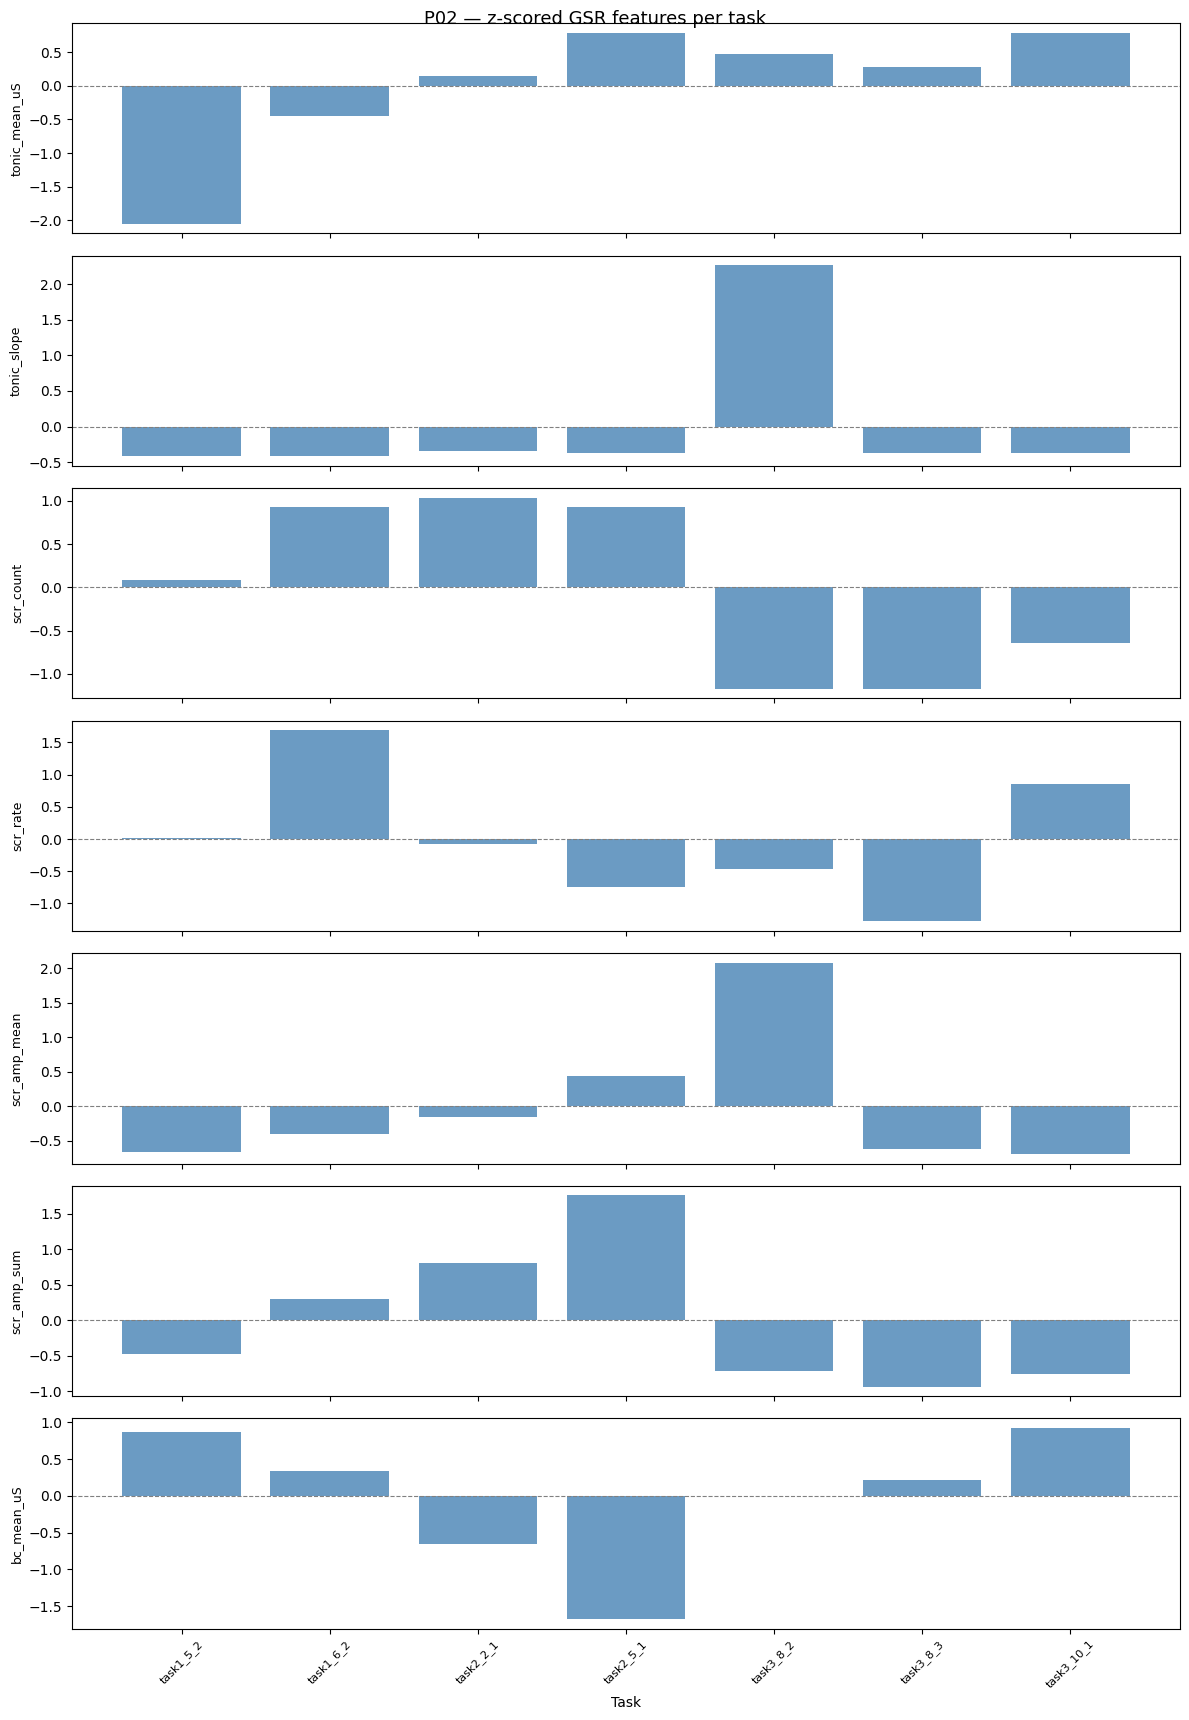

Saved → /content/drive/MyDrive/CAMES/data_collection_training/P02/P02_session1/gsr_P02/P02_features_plot.pdf


In [ ]:
import matplotlib.pyplot as plt

CHECK_PARTICIPANT = "P02"  # ← change as needed

p_df     = features_df[features_df["participant"] == CHECK_PARTICIPANT].copy()
z_cols   = [c + "_z" for c in feature_cols]
n_feats  = len(z_cols)

fig, axes = plt.subplots(n_feats, 1, figsize=(12, 2.5 * n_feats), sharex=True)
fig.suptitle(f"{CHECK_PARTICIPANT} — z-scored GSR features per task", fontsize=13)

for ax, col in zip(axes, z_cols):
    ax.bar(p_df["task_id"], p_df[col], color="steelblue", alpha=0.8)
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_ylabel(col.replace("_z", ""), fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=8)

axes[-1].set_xlabel("Task")
plt.tight_layout()

out_path = os.path.join(BASE_DIR, CHECK_PARTICIPANT,
                        f"{CHECK_PARTICIPANT}_session1",
                        f"gsr_{CHECK_PARTICIPANT}",
                        f"{CHECK_PARTICIPANT}_features_plot.pdf")
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

Notes on the code above: (please address comments to Renia)

Baseline correction removes the within-session tonic drift for a single participant. For each task it subtracts the median conductance from the 60 seconds before that task starts, so the signal is expressed as change from where the participant was at that moment rather than an absolute µS value. The problem it solves is that task 7 might have a higher mean conductance than task 2 simply because the participant has been sweating for longer, not because they were more aroused. Baseline correction makes tasks comparable to each other within the same participant.
Z-scoring operates across participants, not across tasks. It expresses each participant's feature values relative to their own mean and standard deviation across all their tasks. The problem it solves is that P01 has a tonic mean around 12 µS while P03 has one around 3 µS — if you compare raw values across participants, P01 will always dominate simply because of higher absolute conductance. Z-scoring removes that between-participant scale difference so you can ask whether a task was relatively high or low arousal for that individual, regardless of their absolute conductance level.
So in short:

Baseline correction — makes tasks comparable within a participant by removing tonic drift
Z-scoring — makes participants comparable to each other by removing individual differences in absolute conductance level

They are not redundant. You need both because there are two separate sources of unwanted variance in EDA data: session-level drift within a person, and baseline differences between people. Each normalisation step targets a different one.
In practice for your correlation analysis you will use the z-scored features, which already account for both sources of variance. The baseline-corrected signal in the CSV is more of a QC and sanity-check column as we discussed earlier.